# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install kaggle

In [51]:
import pandas as pd
import numpy as np
import shutil
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
## load api token kaggle
print("Upload file kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API token berhasil dikonfigurasi!")

Upload file kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle API token berhasil dikonfigurasi!


In [4]:
## load data
!kaggle datasets download -d ihelon/coffee-sales --unzip

Dataset URL: https://www.kaggle.com/datasets/ihelon/coffee-sales
License(s): CC0-1.0
100% 42.9k/42.9k [00:00<00:00, 38.8MB/s]



In [33]:
df = pd.read_csv('index_1.csv')

df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
## check overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


**Insight**<br>
Semua kolom kecuali *card* sudah lengkap tidak memiliki nilai kosong, namun karena nanti yang akan digunakan hanya *datetime* dan *coffe_name* jadi tidak masasalah jika kolom *card* ada missing values.<br>
Untuk kolom *datetime* masih bertipe data sehingga harus dikonversi terlebih dahulu.

In [34]:
## convert datetime into dtime
df['datetime'] = pd.to_datetime(df['datetime'])

In [7]:
## check duplicate
df.duplicated().sum()

np.int64(0)

**Insight**<br>
Tidak ditemukan adanya duplikasi data.

In [9]:
## check date range coverage
print(f"Start date : {df['datetime'].min()}")
print(f"End date   : {df['datetime'].max()}")
print(f"Total days : {(df['datetime'].max() - df['datetime'].min()).days} hari")

## check the gap
daily = df.set_index('datetime').resample('D').size()
missing_dates = daily[daily == 0]
print(f"\nJumlah hari tanpa transaksi: {len(missing_dates)}")
print(missing_dates)

Start date : 2024-03-01 10:15:50.520000
End date   : 2025-03-23 18:11:38.635000
Total days : 387 hari

Jumlah hari tanpa transaksi: 7
datetime
2024-05-01    0
2024-05-04    0
2024-05-05    0
2024-11-27    0
2025-01-01    0
2025-01-19    0
2025-01-23    0
dtype: int64


**Insight**<br>
Total terdapat satu tahun lebih data yang akan digunakan dari dataset ini dan terdapat 7 hari dimana di hari tersebut tidak ada transaksi. Namun, meski tanpa transaksi kita bisa asumsikan bahwa hari hari tersebut merupakan hari libur atau tidak ada operasional, sehingga tidak perlu kita imputasi.

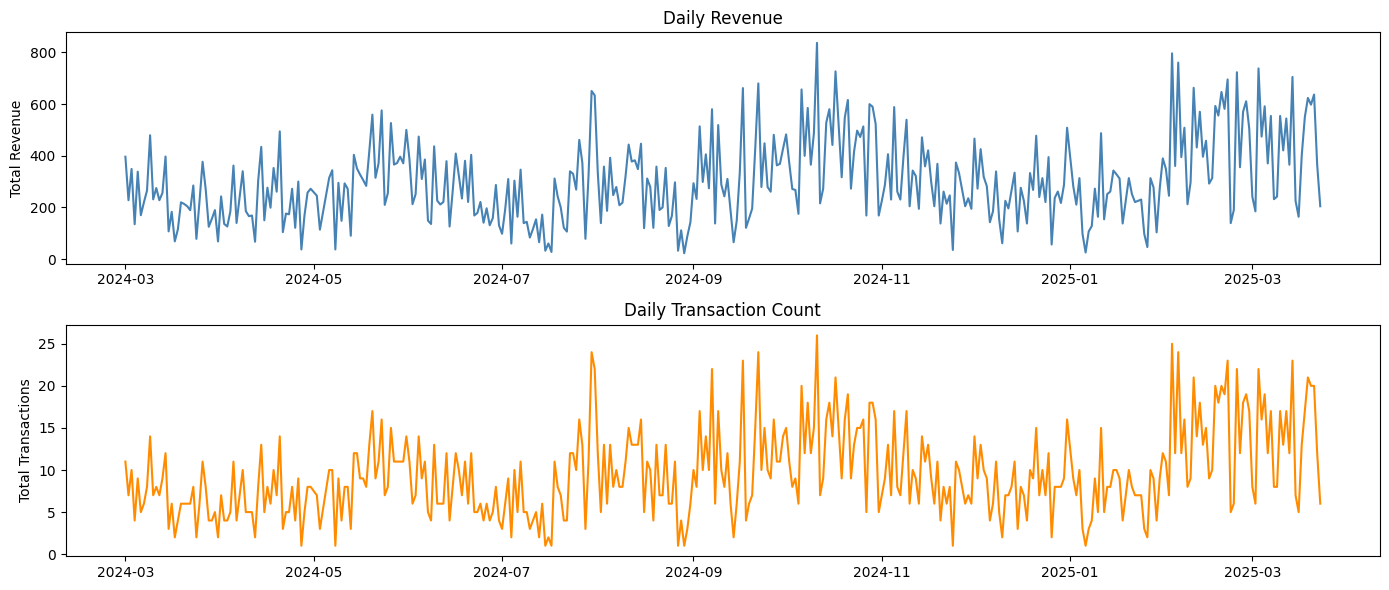

In [10]:
## plot daily timeseries from revenue total and transaction total
daily_revenue = df.groupby(df['datetime'].dt.date)['money'].sum()
daily_transaction = df.groupby(df['datetime'].dt.date)['money'].count()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(daily_revenue.index, daily_revenue.values, color='steelblue')
axes[0].set_title('Daily Revenue')
axes[0].set_ylabel('Total Revenue')

axes[1].plot(daily_transaction.index, daily_transaction.values, color='darkorange')
axes[1].set_title('Daily Transaction Count')
axes[1].set_ylabel('Total Transactions')

plt.tight_layout()
plt.show()

**Insight**<br>
Dari grafik bisa dilihat bahwa pola penjualan cenderung meningkan menjelang akhir tahun. Hal ini mungkin karena orang orang sudah mulai memasuki masa liburan sehingga penjualan secara tidak langsung meningkat. Selain itu, kedua grafik juga berjalan searah yang artinya kenaikan revenue didorong oleh volume transaksi yang tinggi bukan kenaikan harga pertransaksi.

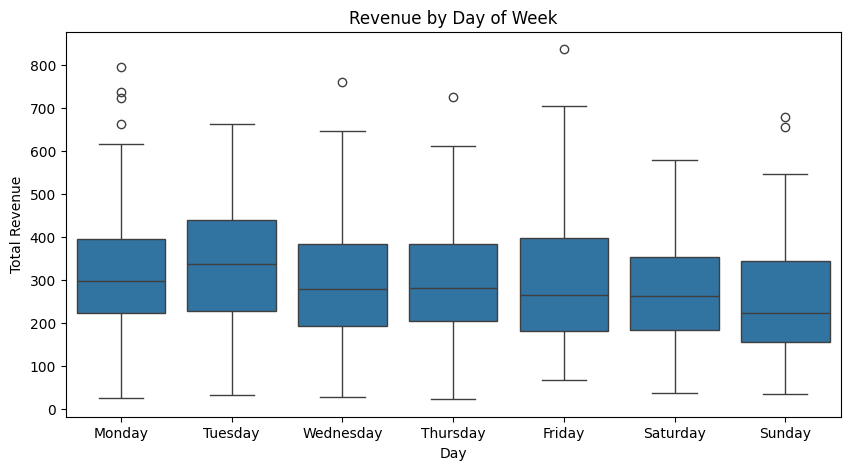

In [11]:
## day of week effect
df['day_of_week'] = df['datetime'].dt.day_name()
daily = df.groupby([df['datetime'].dt.date, 'day_of_week'])['money'].sum().reset_index()
daily.columns = ['date', 'day_of_week', 'revenue']

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(data=daily, x='day_of_week', y='revenue', order=order)
plt.title('Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Revenue')
plt.show()

**Insight**<br>
Terdapat didapatkan pola bahwa weekdays itu lebih ramai dari weekend. Dari sini kita bisa berasumsi bahwa coffeeshop ini ada di daerah yang ramai saat weekdays, misalnya area perkantoran atau kampus. Sehingga pengetahuan apakah sedang weekend atau weekdays itu akan sangat berguna dalam menentukan forecast.

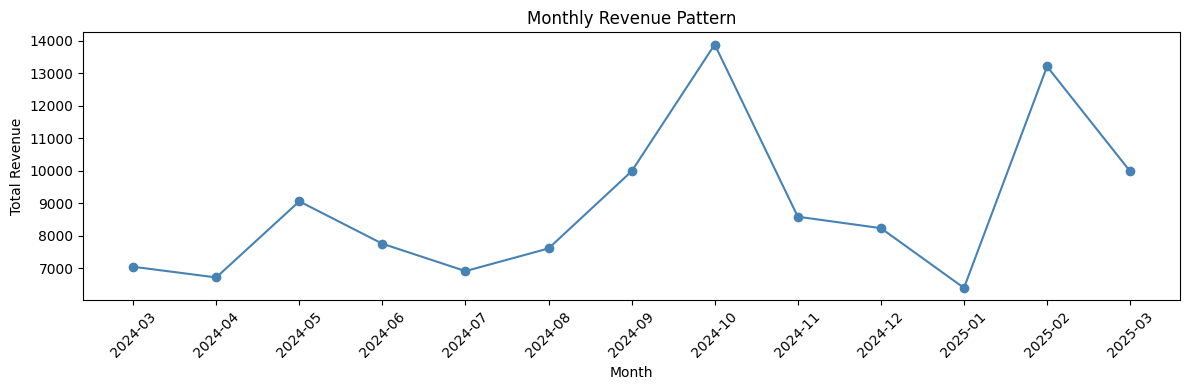

In [13]:
## check monthly pattern
df['month'] = df['datetime'].dt.month_name()
monthly = df.groupby(df['datetime'].dt.to_period('M'))['money'].sum().reset_index()
monthly.columns = ['month', 'revenue']

plt.figure(figsize=(12, 4))
plt.plot(monthly['month'].astype(str), monthly['revenue'], marker='o', color='steelblue')
plt.title('Monthly Revenue Pattern')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**<br>
Ternyata asumsi kita terhadap sales yang naik pada saat menjelang tahun baru itu keliru. Setelah dilihat lebih detail ternyata akhir tahun dan bulan pertama di tahun baru malah terendah. Hal ini semakin menguatkan asumsi kita mengenai coffeeshop ini berada di area produktif seperti perkantoran atau yang paling kuat asumsinya ada di kampus.

/tmp/ipykernel_1219/1206770385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coffee_revenue.values, y=coffee_revenue.index, palette='Blues_r')


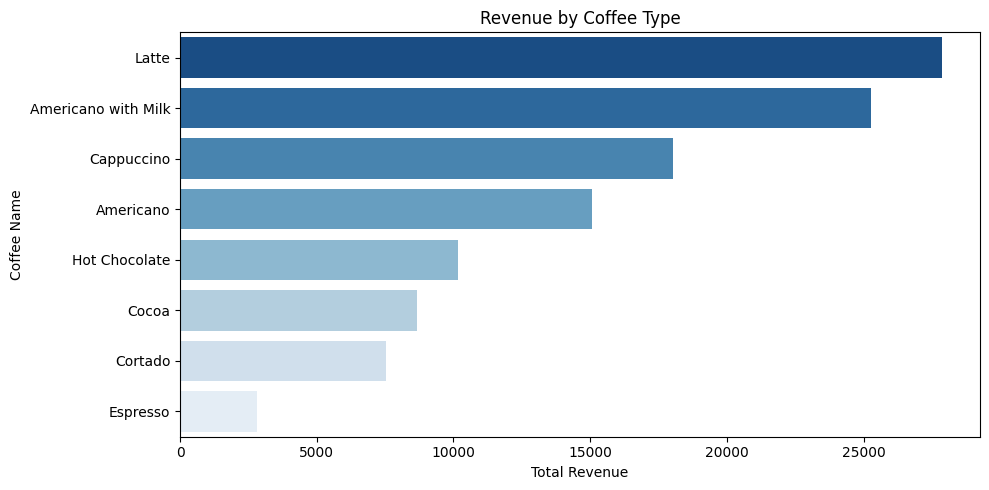

In [15]:
## breakdown coffee menu type
coffee_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=coffee_revenue.values, y=coffee_revenue.index, palette='Blues_r')
plt.title('Revenue by Coffee Type')
plt.xlabel('Total Revenue')
plt.ylabel('Coffee Name')
plt.tight_layout()
plt.show()

**Insight**<br>
Didapatkan bahwa ternyata kopi yang memberikan revenue paling banyak itu ada latte, americano with milk, cappuccino, dan americano.

                     volume   revenue  avg_price
coffee_name                                     
Latte                   782  27866.30  35.634655
Americano with Milk     824  25269.12  30.666408
Cappuccino              501  18034.14  35.996287
Americano               578  15062.26  26.059273
Hot Chocolate           282  10172.46  36.072553
Cocoa                   243   8678.16  35.712593
Cortado                 292   7534.86  25.804315
Espresso                134   2814.28  21.002090


/tmp/ipykernel_1219/2381709021.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary['volume'].values, y=summary.index, palette='Oranges_r', ax=axes[0])
/tmp/ipykernel_1219/2381709021.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary['avg_price'].values, y=summary.index, palette='Greens_r', ax=axes[1])


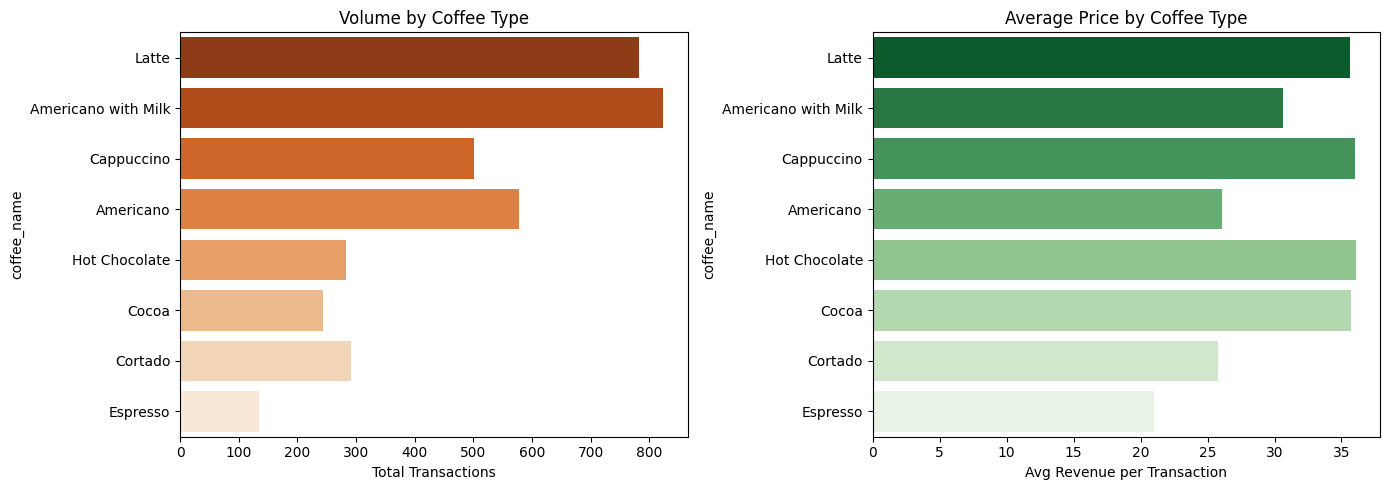

In [16]:
## check if the higest selling is the profitable one
coffee_volume = df.groupby('coffee_name')['money'].count()
coffee_revenue = df.groupby('coffee_name')['money'].sum()
coffee_avg = df.groupby('coffee_name')['money'].mean()

summary = pd.DataFrame({'volume': coffee_volume, 'revenue': coffee_revenue, 'avg_price': coffee_avg}).sort_values('revenue', ascending=False)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=summary['volume'].values, y=summary.index, palette='Oranges_r', ax=axes[0])
axes[0].set_title('Volume by Coffee Type')
axes[0].set_xlabel('Total Transactions')

sns.barplot(x=summary['avg_price'].values, y=summary.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Average Price by Coffee Type')
axes[1].set_xlabel('Avg Revenue per Transaction')

plt.tight_layout()
plt.show()

**Insight**<br>
produk paling profitable adalah Latte dan Americano with Milk. Keduanya tinggi di volume sekaligus revenue. Yang menarik adalah Cappuccino dan Hot Chocolate volumenya tidak terlalu tinggi tapi average pricenya justru setara Latte, artinya keduanya adalah produk dengan margin baik tapi kurang populer.

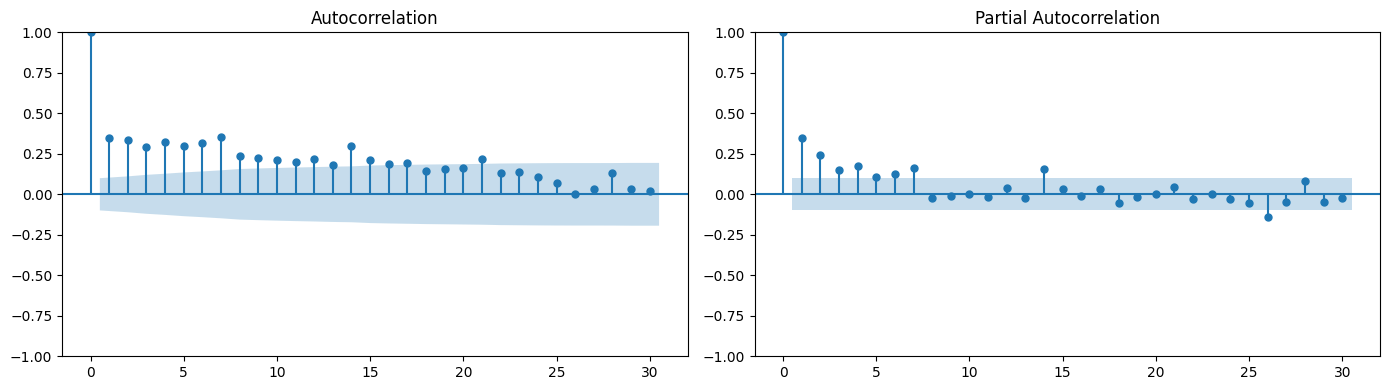

In [22]:
## check the acf & pacf
daily_sales = df.groupby(df['datetime'].dt.date)['coffee_name'].count()
daily_sales.index = pd.to_datetime(daily_sales.index)
daily_sales = daily_sales.asfreq('D', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(daily_sales, lags=30, ax=axes[0])
plot_pacf(daily_sales, lags=30, ax=axes[1])
plt.tight_layout()
plt.show()

**Insight**<br>
Diketahui pada acf, lag 1, 2, 7, 14 melewati batas signifikansi, artinya penjualan hari ini berkorelasi dengan 1, 2, 7, dan 14 hari yang lalu. Sedangkan pada pacf, hanya lag 1 dan 2 yang benar-benar signifikan secara independen setelah efek lag lain dihilangkan. Sehingga kita bisa mengambil lag 1, 2, 7 dan 14.

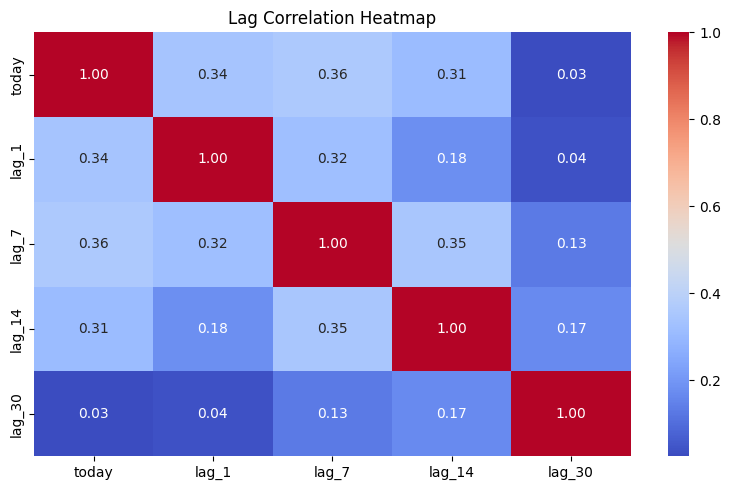

In [29]:
## check the lag correlation heatmap
lag_df = pd.DataFrame({'today': daily_sales})
for lag in [1, 7, 14, 30]:
    lag_df[f'lag_{lag}'] = daily_sales.shift(lag)
lag_df = lag_df.dropna()

plt.figure(figsize=(8, 5))
sns.heatmap(lag_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Lag Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight**<br>
Heatmap ini mengkonfirmasi analisis sebelumnya bahwa memang lag 1, 2, 7, dan 14 layak untuk digunakan.

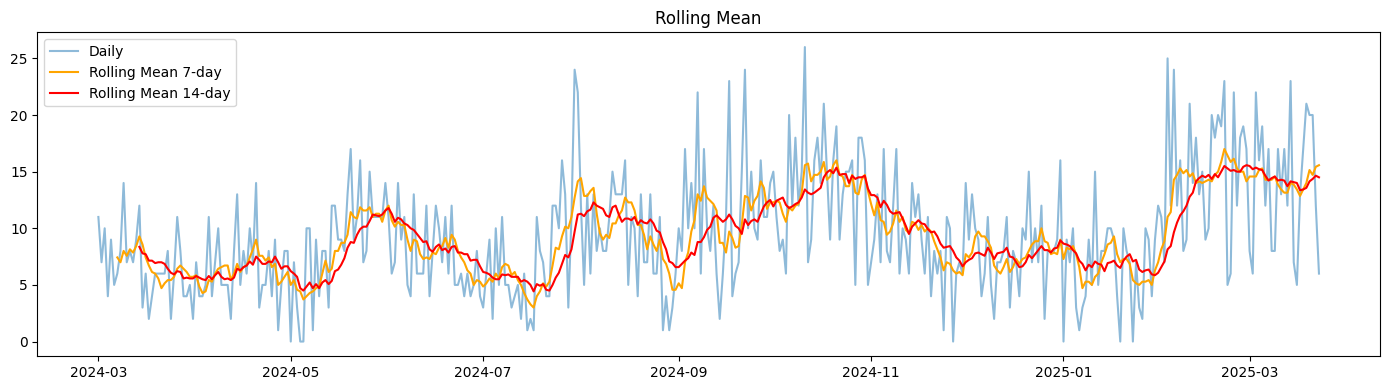

In [28]:
## check the rolling mean
plt.figure(figsize=(14, 4))
plt.plot(daily_sales, label='Daily', alpha=0.5)
plt.plot(daily_sales.rolling(7).mean(), label='Rolling Mean 7-day', color='orange')
plt.plot(daily_sales.rolling(14).mean(), label='Rolling Mean 14-day', color='red')
plt.title('Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**<br>
Berdasarkan chart, bisa dilihat bahwa rolling mean 7 lebih responsive dibanding dengan 14.

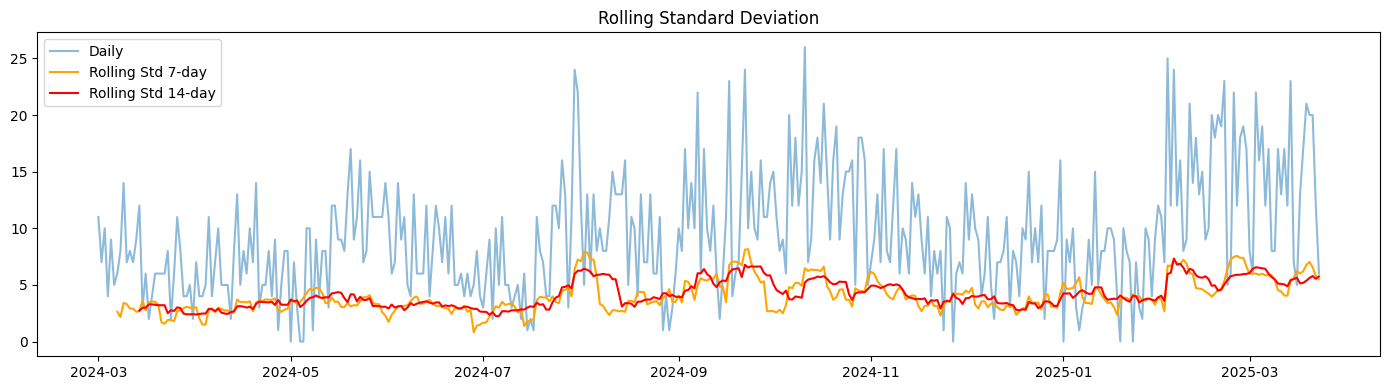

In [26]:
## check rolling std
plt.figure(figsize=(14, 4))
plt.plot(daily_sales, label='Daily', alpha=0.5)
plt.plot(daily_sales.rolling(7).std(), label='Rolling Std 7-day', color='orange')
plt.plot(daily_sales.rolling(14).std(), label='Rolling Std 14-day', color='red')
plt.title('Rolling Standard Deviation')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**<br>
Berdasarkan chart, bisa dilihat bahwa rolling std 7 dan 14 cukup identik. Namun tetap, rolling std 7 lebih responsive.

In [31]:
## stationarity test
result = adfuller(daily_sales)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

if result[1] < 0.05:
    print("\nData STASIONER — fitur lag valid digunakan")
else:
    print("\nData TIDAK STASIONER — perlu differencing")

ADF Statistic : -3.0621
p-value       : 0.0295
Critical Values:
   1%: -3.4476
   5%: -2.8692
   10%: -2.5708

Data STASIONER — fitur lag valid digunakan


**Insight**<br>
Didapatkan, tidak ada trend atau seasonality yang persisten yang perlu dihilangkan. Ini berarti fitur lag_1, lag_2, lag_7, lag_14, rolling mean, dan rolling std valid untuk langsung digunakan.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [35]:
## drop not used colums
df = df.drop(columns=['datetime', 'cash_type', 'card', 'money'])
df.head()

,date,coffee_name
0,2024-03-01,Latte
1,2024-03-01,Hot Chocolate
2,2024-03-01,Hot Chocolate
3,2024-03-01,Americano
4,2024-03-01,Latte


**Insight**<br>
Sekarang dataset hanya menyisakan data yang diperlukan saja, namun nanti dibawah akan dilakukan penambahan fitur melalui feature engineering.

In [38]:
## aggregate per day in wide format
daily_product = df.groupby([df['date'], 'coffee_name']).size().unstack(fill_value=0)
daily_product.index = pd.to_datetime(daily_product.index)
daily_product.head()

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
date,,,,,,,,
2024-03-01,1,4,0,1,0,0,3,2
2024-03-02,3,3,0,0,0,0,0,1
2024-03-03,1,2,0,1,2,0,2,2
2024-03-04,0,1,0,0,0,1,0,2
2024-03-05,0,0,0,1,1,0,4,3


**Insight**<br>
Bentuk data sudah berubah menjadi wide format dengan setiap menu menjadi kolom data dan indexny berdasarkan tanggal

In [40]:
## fill the non operational day with 0s
daily_product = daily_product.asfreq('D', fill_value=0)
print(f"Total hari setelah reindex: {len(daily_product)}")
print(daily_product[daily_product.sum(axis=1) == 0])

Total hari setelah reindex: 388
coffee_name  Americano  Americano with Milk  Cappuccino  Cocoa  Cortado  \
date                                                                      
2024-05-01           0                    0           0      0        0   
2024-05-04           0                    0           0      0        0   
2024-05-05           0                    0           0      0        0   
2024-11-27           0                    0           0      0        0   
2025-01-01           0                    0           0      0        0   
2025-01-19           0                    0           0      0        0   
2025-01-23           0                    0           0      0        0   

coffee_name  Espresso  Hot Chocolate  Latte  
date                                         
2024-05-01          0              0      0  
2024-05-04          0              0      0  
2024-05-05          0              0      0  
2024-11-27          0              0      0  
2025-01-01      

**Insight**<br>
Karena asumsi kita nilai yang kosong itu saat coffeeshop tutup, berarti tidak perlu kita drop, kita isi 0 saja.

In [41]:
## make temporal fetures
daily_product['day_of_week'] = daily_product.index.dayofweek
daily_product['is_weekend'] = daily_product['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
daily_product['month'] = daily_product.index.month
daily_product['week_of_year'] = daily_product.index.isocalendar().week.astype(int)

In [42]:
## make lag & rolling features
coffee_cols = ['Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte']

for col in coffee_cols:
    daily_product[f'{col}_lag1']  = daily_product[col].shift(1)
    daily_product[f'{col}_lag2']  = daily_product[col].shift(2)
    daily_product[f'{col}_lag7']  = daily_product[col].shift(7)
    daily_product[f'{col}_lag14'] = daily_product[col].shift(14)
    daily_product[f'{col}_roll_mean7'] = daily_product[col].shift(1).rolling(7).mean()
    daily_product[f'{col}_roll_std7']  = daily_product[col].shift(1).rolling(7).std()

## drop nan because of lag
daily_product = daily_product.dropna()
print(daily_product.shape)
print(daily_product.head())

(374, 60)
coffee_name  Americano  Americano with Milk  Cappuccino  Cocoa  Cortado  \
date                                                                      
2024-03-15           1                    0           0      0        0   
2024-03-16           1                    2           0      0        3   
2024-03-17           0                    0           0      0        1   
2024-03-18           3                    0           0      0        1   
2024-03-19           0                    1           0      0        1   

coffee_name  Espresso  Hot Chocolate  Latte  day_of_week  is_weekend  ...  \
date                                                                  ...   
2024-03-15          0              1      1            4           0  ...   
2024-03-16          0              0      0            5           1  ...   
2024-03-17          0              0      1            6           1  ...   
2024-03-18          0              0      0            0           0  ...   
20

In [43]:
## encode day_of_week
daily_product = pd.get_dummies(daily_product, columns=['day_of_week'], prefix='dow', dtype=int)
print(daily_product.shape)
print(daily_product.head())

(374, 66)
            Americano  Americano with Milk  Cappuccino  Cocoa  Cortado  \
date                                                                     
2024-03-15          1                    0           0      0        0   
2024-03-16          1                    2           0      0        3   
2024-03-17          0                    0           0      0        1   
2024-03-18          3                    0           0      0        1   
2024-03-19          0                    1           0      0        1   

            Espresso  Hot Chocolate  Latte  is_weekend  month  ...  \
date                                                           ...   
2024-03-15         0              1      1           0      3  ...   
2024-03-16         0              0      0           1      3  ...   
2024-03-17         0              0      1           1      3  ...   
2024-03-18         0              0      0           0      3  ...   
2024-03-19         0              2      2         

**Insight**<br>
Karena day_of_week itu masih berupa string nama hari, jadi diencode terlebih dahulu agar bisa diproses oleh ml.

In [45]:
target_cols = coffee_cols
feature_cols = [col for col in daily_product.columns if col not in target_cols]
X = daily_product[feature_cols]

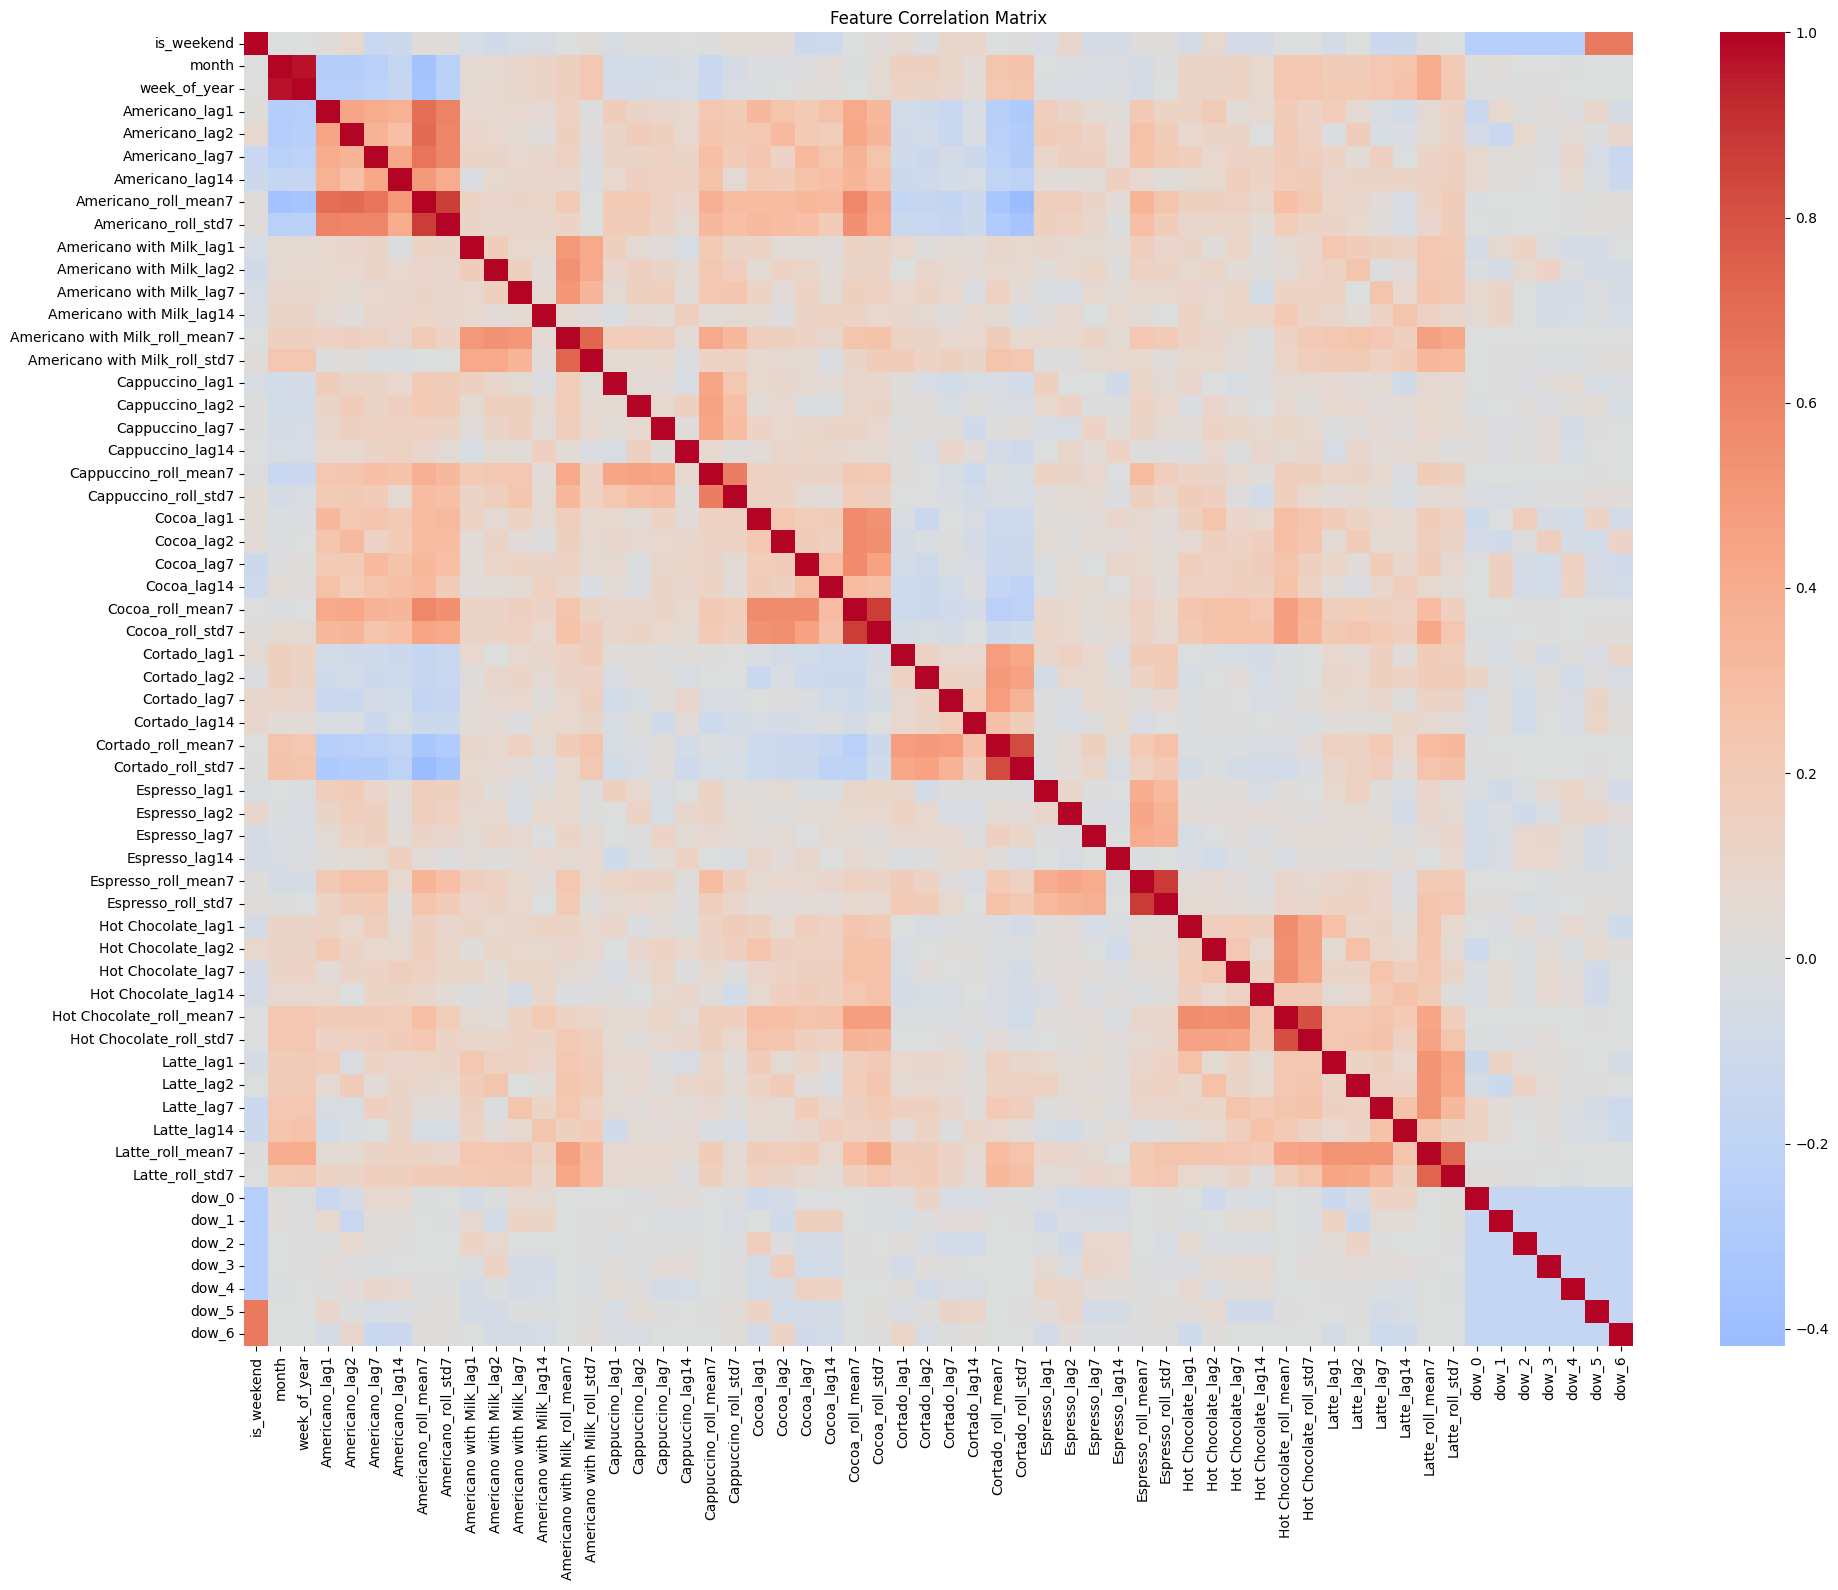

In [46]:
## correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [47]:
## vif
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                           feature        VIF
0                       is_weekend        inf
56                           dow_5        inf
57                           dow_6        inf
1                            month  17.656714
2                     week_of_year  17.554080
7             Americano_roll_mean7  13.631920
25                Cocoa_roll_mean7   8.358889
37             Espresso_roll_mean7   7.179431
43        Hot Chocolate_roll_mean7   6.845666
49                Latte_roll_mean7   6.553933
13  Americano with Milk_roll_mean7   6.288440
38              Espresso_roll_std7   5.886333
26                 Cocoa_roll_std7   5.837829
52                           dow_1   5.654222
51                           dow_0   5.439879
55                           dow_4   5.390811
54                           dow_3   5.277441
8              Americano_roll_std7   5.210916
31              Cortado_roll_mean7   5.194459
53                           dow_2   5.050471
32               Cortado_roll_std7

In [48]:
## drop the features we dont need
cols_to_drop = ['is_weekend', 'week_of_year', 'dow_5', 'dow_6'] + \
               [col for col in daily_product.columns if 'roll_mean7' in col]

daily_product = daily_product.drop(columns=cols_to_drop)
print(daily_product.shape)
print(daily_product.columns.tolist())

(374, 54)
['Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte', 'month', 'Americano_lag1', 'Americano_lag2', 'Americano_lag7', 'Americano_lag14', 'Americano_roll_std7', 'Americano with Milk_lag1', 'Americano with Milk_lag2', 'Americano with Milk_lag7', 'Americano with Milk_lag14', 'Americano with Milk_roll_std7', 'Cappuccino_lag1', 'Cappuccino_lag2', 'Cappuccino_lag7', 'Cappuccino_lag14', 'Cappuccino_roll_std7', 'Cocoa_lag1', 'Cocoa_lag2', 'Cocoa_lag7', 'Cocoa_lag14', 'Cocoa_roll_std7', 'Cortado_lag1', 'Cortado_lag2', 'Cortado_lag7', 'Cortado_lag14', 'Cortado_roll_std7', 'Espresso_lag1', 'Espresso_lag2', 'Espresso_lag7', 'Espresso_lag14', 'Espresso_roll_std7', 'Hot Chocolate_lag1', 'Hot Chocolate_lag2', 'Hot Chocolate_lag7', 'Hot Chocolate_lag14', 'Hot Chocolate_roll_std7', 'Latte_lag1', 'Latte_lag2', 'Latte_lag7', 'Latte_lag14', 'Latte_roll_std7', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4']


**Insight**<br>
Berdasarkan analisis korelasi, beberapa fitur yang tidak dibutuhkan di drop dan hanya menyisakan yang digunakan saja.

In [50]:
## split data
split_train = '2024-12-01'
split_val   = '2025-02-01'

train = daily_product[daily_product.index < split_train]
val   = daily_product[(daily_product.index >= split_train) & (daily_product.index < split_val)]
test  = daily_product[daily_product.index >= split_val]

print(f"Train: {train.index.min()} → {train.index.max()} ({len(train)} hari)")
print(f"Val  : {val.index.min()} → {val.index.max()} ({len(val)} hari)")
print(f"Test : {test.index.min()} → {test.index.max()} ({len(test)} hari)")

Train: 2024-03-15 00:00:00 → 2024-11-30 00:00:00 (261 hari)
Val  : 2024-12-01 00:00:00 → 2025-01-31 00:00:00 (62 hari)
Test : 2025-02-01 00:00:00 → 2025-03-23 00:00:00 (51 hari)


**Insight**<br>
Dilakukan splitting menjadi train, val, test dengan berdasarkan rentang tanggal agar timeseries tidak menjadi berantakan jika menggunakan random.

In [52]:
## scaler
target_cols = ['Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte']
feature_cols = [col for col in daily_product.columns if col not in target_cols]

scaler = StandardScaler()

X_train = scaler.fit_transform(train[feature_cols])
X_val   = scaler.transform(val[feature_cols])
X_test  = scaler.transform(test[feature_cols])

y_train = train[target_cols]
y_val   = val[target_cols]
y_test  = test[target_cols]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (261, 46), y_train: (261, 8)
X_val  : (62, 46),   y_val  : (62, 8)
X_test : (51, 46),  y_test : (51, 8)
